In [ ]:
# OPTIONAL

import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# Data
data = {
    "Hours": [2, 4, 6, 8],
    "Result": [0, 0, 1, 1]
}

df = pd.DataFrame(data)

X = df[['Hours']]
y = df['Result']

# Model
model = LogisticRegression()
model.fit(X, y)

# Prediction
hours = np.array([[5]])
prob = model.predict_proba(hours)

print("Probability of Pass:", prob[0][1])
print("Prediction:", model.predict(hours))

# Plot
x_range = np.linspace(0,10,100).reshape(-1,1)
y_prob = model.predict_proba(x_range)[:,1]

plt.scatter(X, y)
plt.plot(x_range, y_prob)
plt.xlabel("Study Hours")
plt.ylabel("Probability of Pass")
plt.title("Logistic Regression Curve")
plt.show()

# TASK SOLUTION

In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


<!-- STEP 0: Understand the Problem (Don’t Skip This) -->
    

👉 Target:

Churn → Yes / No

👉 Goal:

Predict whether a customer will leave (1) or stay (0)

<!-- STEP 1: Data Understanding -->

From your dataset:

Mix of categorical + numerical features
Target is categorical (Yes/No) → needs conversion

<!-- STEP 2: Data Cleaning (CRITICAL) -->

⚠️ Hidden Issue in Your Data

👉 TotalCharges looks numeric but is actually string

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df = df.dropna()

# 👉 If you skip this → model will silently break or perform badly

In [4]:
# STEP 3: Convert Target Variable

df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

C:\Users\vidhu\AppData\Local\Temp\ipykernel_20028\4284107399.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})


In [6]:
# STEP 4: Drop Useless Columns

df = df.drop('customerID',axis=1)

# 👉 ID columns = noise

In [7]:
# STEP 5: Encode Categorical Variables

df = pd.get_dummies(df, drop_first = True)



# 👉 This converts:

# gender → Male/Female → 0/1
# Contract → multiple columns

In [11]:
# STEP 6: Split Data

from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis = 1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)


In [13]:
# STEP 7: Feature Scaling (MOST PEOPLE IGNORE THIS)

# 👉 Logistic regression is distance-sensitive

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [15]:
# STEP 8: Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
# STEP 9: Model Prediction

# 👉 Class Prediction

y_pred = model.predict(X_test)

In [17]:
# 👉 Probability Prediction (IMPORTANT)

y_prob = model.predict_proba(X_test)[:,1]


# 👉 This gives:
# Probability of churn = 1

In [18]:
# STEP 10: Evaluate Model (REAL ANALYSIS)

# Accuracy (Basic — not enough)

from sklearn.metrics import accuracy_score

print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.7867803837953091


In [19]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[914 119]
 [181 193]]


In [20]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [21]:
# ROC AUC Score (IMPORTANT)

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.8319494126965228


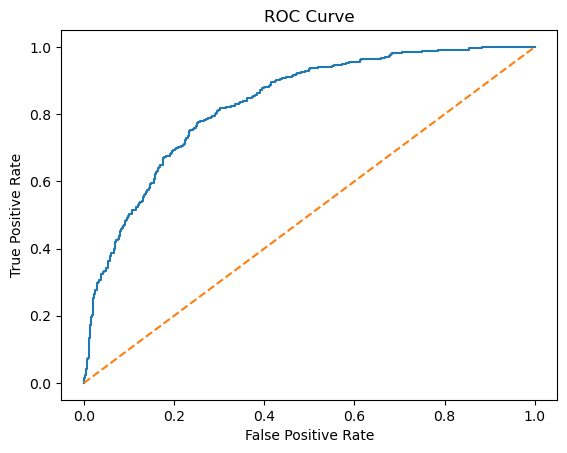

In [22]:
# STEP 11: ROC Curve Plot

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# 1. TPR (True Positive Rate) - Y-axis
# 2. FPR (False Positive Rate) - X-axis

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [23]:
# STEP 12: Real Prediction (Single Customer)

sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)
probability = model.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.99422296 0.00577704]]


In [ ]:
# FINAL OUTPUT INTERPRETATION

Prediction: 1
Probability: 0.78
    

# 👉 Means:

# 78% chance customer will leave
# Model says → Churn